# UNSW-NB15 Preprocessing Notebook
This notebook preprocesses UNSW-NB15 data into a model-ready format.

## Pipeline summary
1. Load raw UNSW training data.
2. Inspect schema and class distribution.
3. Drop non-informative columns and duplicate rows.
4. Encode categorical features.
5. Normalize numeric features.
6. Perform train/test split.
7. Visualize class balance and correlations.
8. Export cleaned dataset to `../data_processed/unsw_nb15_cleaned.csv`.

In [2]:
import pandas as pd

df = pd.read_csv("../data_raw/unsw_nb15/UNSW_NB15_training-set.csv")
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## Step A: Load and Inspect
These cells load UNSW-NB15 data and inspect schema/summary statistics.
Use this stage to confirm expected columns and class labels before transformations.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [4]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [5]:
df['label'].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

In [6]:
df = df.drop(columns=["id"])

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["proto"] = le.fit_transform(df["proto"])
df["service"] = le.fit_transform(df["service"])
df["state"] = le.fit_transform(df["state"])
df["attack_cat"] = le.fit_transform(df["attack_cat"])

In [8]:
df = df.drop_duplicates()

## Step B: Clean, Transform, and Split
This stage applies categorical encoding, duplicate removal, scaling, and train/test split.
The objective is to create stable numeric features suitable for ML training.

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = df.select_dtypes(include=["int64","float64"]).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

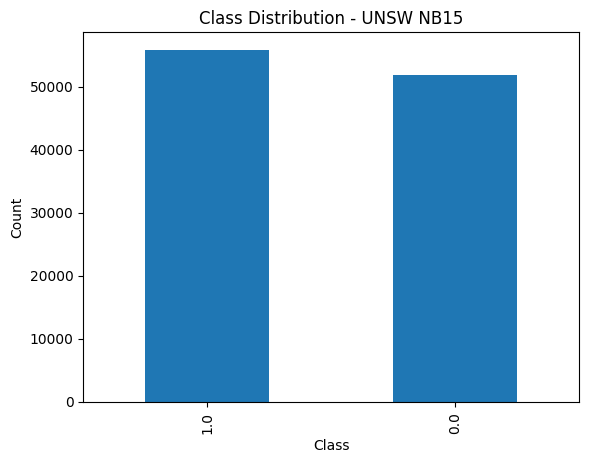

In [11]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution - UNSW NB15")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Step C: Diagnose Imbalance and Export
Plots and class reports explain imbalance severity, which is critical for IDS datasets.
The final export stores the cleaned dataframe in `../data_processed/`.

In [1]:
# Minority class percentage and imbalance ratio report
# This cell can run even if df is not already loaded in memory.
import os
import pandas as pd

if "df" not in globals():
    cleaned_path = "../data_processed/unsw_nb15_cleaned.csv"
    raw_path = "../data_raw/unsw_nb15/UNSW_NB15_training-set.csv"

    if os.path.exists(cleaned_path):
        df = pd.read_csv(cleaned_path)
    elif os.path.exists(raw_path):
        df = pd.read_csv(raw_path)
    else:
        raise FileNotFoundError("UNSW-NB15 files not found in data_processed or data_raw paths.")

label_col = "label" if "label" in df.columns else "Label" if "Label" in df.columns else None
if label_col is None:
    raise KeyError("No label column found. Expected 'label' or 'Label'.")

class_counts = df[label_col].value_counts().sort_values(ascending=False)

total_samples = class_counts.sum()
minority_class = class_counts.idxmin()
minority_count = class_counts.min()
majority_count = class_counts.max()

minority_percentage = (minority_count / total_samples) * 100
imbalance_ratio = majority_count / minority_count

class_report = (class_counts / total_samples * 100).rename("percentage").reset_index()
class_report.columns = ["class", "percentage"]

print("Minority class:", minority_class)
print("Minority class count:", minority_count)
print("Minority class percentage: {:.4f}%".format(minority_percentage))
print("Imbalance ratio (majority/minority): {:.4f}".format(imbalance_ratio))

class_report

Minority class: 0.0
Minority class count: 51890
Minority class percentage: 48.1622%
Imbalance ratio (majority/minority): 1.0763


,class,percentage
0,1.0,51.837758
1,0.0,48.162242


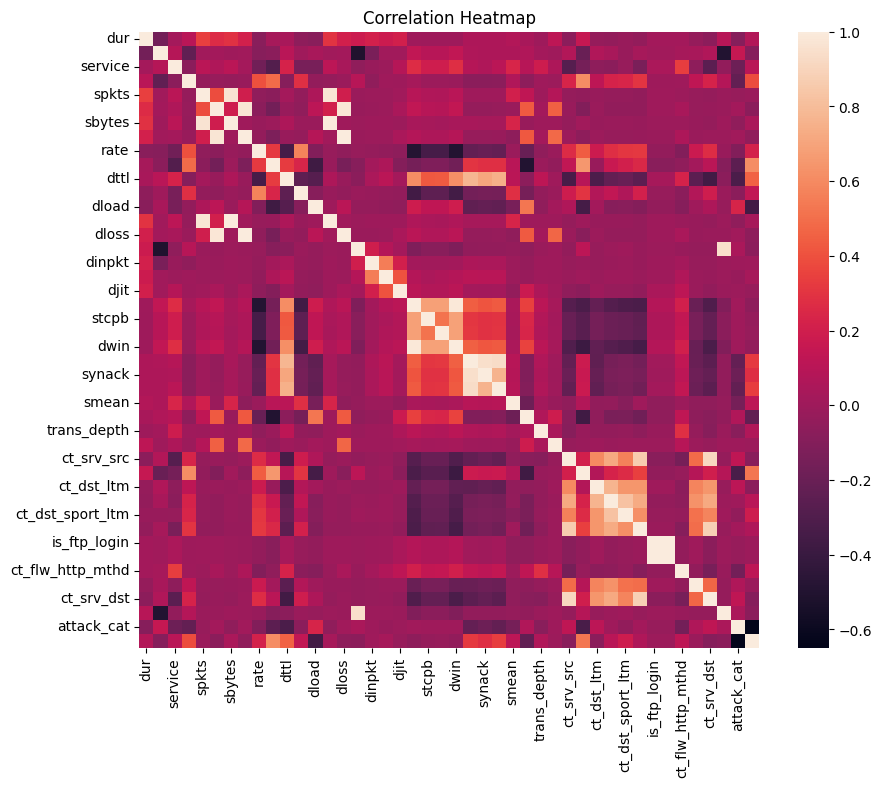

In [12]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")
plt.show()

In [13]:
df.to_csv("../data_processed/unsw_nb15_cleaned.csv", index=False)